## filter by resolution (< 3.0) and deposition (2021/09/30)

In [12]:
import pandas as pd

# CSV 파일 불러오기 (열 이름 없음)
metadata = pd.read_csv("/public_data/BioMolDB_2024Oct21/metadata/ID_to_deposition.csv", header=None)

# 날짜, 해상도 열 추출
metadata[1] = pd.to_datetime(metadata[1], errors='coerce')  # 날짜 형식으로 변환
metadata[2] = pd.to_numeric(metadata[2], errors='coerce')   # 숫자형으로 변환

# 조건: 2021-09-30 이전 & resolution < 3
filtered = metadata[
    (metadata[1] < pd.to_datetime('2021-09-30')) &
    (metadata[2] <= 3)
]

# 결과 저장
filtered.to_csv('/home/psh/protein-frame-flow/parse_general/meta/resolution_3.0.csv', index=False, header=False)


## check number of samples by resolution threshold 

/tmp/ipykernel_3097984/2496211008.py:20: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3097984/2496211008.py:20: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3097984/2496211008.py:20: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3097984/2496211008.py:20: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3097984/2496211008.py:20: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3097984/2496211008.py:20: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3097984/2496211008.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Dej

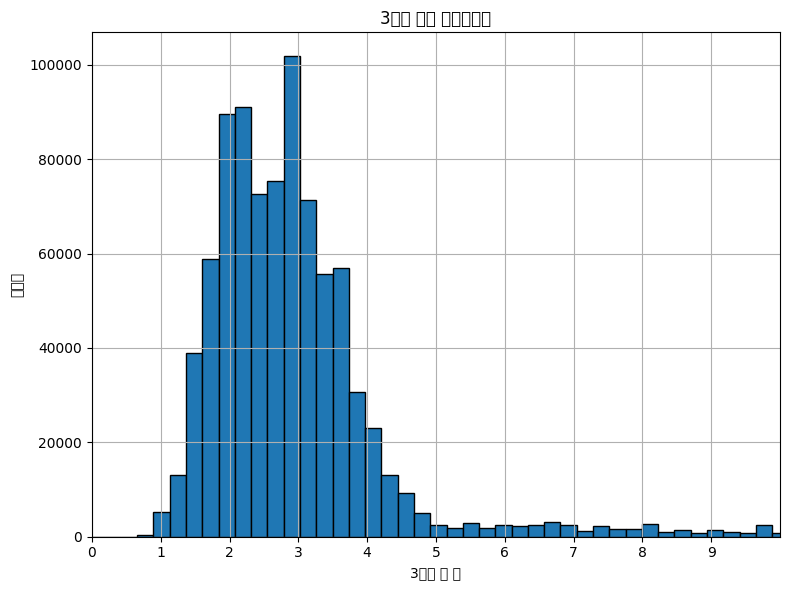

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 읽기
csv_path = "/public_data/BioMolDB_2024Oct21/metadata/metadata_psk.csv"
df = pd.read_csv(csv_path)

# 3번째 열 추출 (0-indexed이므로 인덱스 2)
third_column = df.iloc[:, 2]

# 히스토그램 그리기
plt.figure(figsize=(8, 6))
plt.hist(third_column.dropna(), bins=300, edgecolor='black')
plt.xlim((0,10))
plt.xticks([i for i in range(10)])
plt.xlabel("3번째 열 값")
plt.ylabel("빈도수")
plt.title("3번째 열의 히스토그램")
plt.grid(True)
plt.tight_layout()
plt.show()


# parse_general/utils로 나온 결과물

In [6]:
atom_ratio_path = '/home/psh/protein-frame-flow/experiments/logs/all_atom.log'
multi_model_path = '/home/psh/protein-frame-flow/parse_general/meta/multi_model_pdbs.txt'
missing_path = '/home/psh/protein-frame-flow/parse_general/meta/missing_residue_ratios.txt'
d_amino_path = '/home/psh/protein-frame-flow/parse_general/meta/pdbs_with_d_amino_acid.txt'

deleted_ids = []
with open(atom_ratio_path, "r") as f:
    for line in f:
        if "ratio" in line:
            deleted_ids.append(line[:4].strip())

with open(multi_model_path, "r") as f:
    for line in f:
        deleted_ids.append(line.strip())

with open(missing_path, "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            pdb_id, value = parts
            if float(value) >= 0.5:
                deleted_ids.append(pdb_id.strip())

with open(d_amino_path, 'r') as f:
    for line in f:
        deleted_ids.append(line.strip())

output_file = "/home/psh/protein-frame-flow/parse_general/meta/deleted_pdbs.txt"

# 파일로 저장 (한 줄에 하나씩)
with open(output_file, "w") as f:
    for pdb_id in deleted_ids:
        f.write(pdb_id + "\n")

In [ ]:
# 파일 경로
file1 = "/home/psh/protein-frame-flow/parse_general/meta/only_protein_1.txt"
file2 = "/home/psh/protein-frame-flow/parse_general/meta/deleted_pdbs.txt"
output_file = "/home/psh/protein-frame-flow/parse_general/meta/only_protein_1.txt"

# 파일 읽기
with open(file1, "r") as f:
    ids1 = set(line.strip() for line in f)

with open(file2, "r") as f:
    ids2 = set(line.strip() for line in f)

# 차집합: ids1 중 ids2에 없는 것만 추출
filtered_ids = sorted(ids1 - ids2)

# 결과 저장
with open(output_file, "w") as f:
    for pdb_id in filtered_ids:
        f.write(pdb_id + "\n")

## make metadata_psh 

In [ ]:
import pandas as pd

# 파일 경로
csv_input_path = "/public_data/BioMolDB_2024Oct21/metadata/metadata_psk.csv"
txt_path = "/home/psh/protein-frame-flow/parse_general/only_protein_filtered.txt"
csv_output_path = "/home/psh/protein-frame-flow/parse_general/metadata_psh.csv"

# 1. 텍스트 파일에서 유효한 PDB ID 불러오기
with open(txt_path, 'r') as f:
    valid_ids = set(line.strip().lower() for line in f if line.strip())

# 2. metadata_psk.csv 파일 불러오기
df = pd.read_csv(csv_input_path)

# 3. CHAINID 열에서 PDB ID 추출 (예: 1ABC_A → 1abc)
pdb_ids_from_chainid = df["CHAINID"].astype(str).str.split('_').str[0].str.lower()

# 4. valid_ids에 포함되는 PDB ID만 필터링
filtered_df = df[pdb_ids_from_chainid.isin(valid_ids)]

# 5. 필터링된 결과 저장
filtered_df.to_csv(csv_output_path, index=False)

print(f"{len(filtered_df)}개의 행이 저장되었습니다: {csv_output_path}")


160939개의 행이 저장되었습니다: /home/psh/protein-frame-flow/parse_interface/metadata_psh.csv


## polymer mask 정제하기 

In [9]:
import os
import json

def group_close_values(values, threshold=5):
    if not values:
        return []

    values = sorted(values)
    grouped = [[values[0]]]

    for v in values[1:]:
        if v - grouped[-1][-1] < threshold:
            grouped[-1].append(v)
        else:
            grouped.append([v])

    return grouped

def process_interface_directory(json_dir):
    for filename in os.listdir(json_dir):
        if not filename.endswith('.json'):
            continue

        filepath = os.path.join(json_dir, filename)

        with open(filepath, 'r') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                print(f"Skipping invalid JSON file: {filename}")
                continue

        if "interface_residues" not in data:
            print(f"Skipping {filename}: no 'interface_residues' key.")
            continue

        skip_file = False
        for chain_idx, residue_list in data["interface_residues"].items():
            # 이미 그룹핑되어 있다면 (리스트 안에 또 리스트가 있는 경우)
            if residue_list and isinstance(residue_list[0], list):
                print(f"Skipping {filename}: already grouped.")
                skip_file = True
                break
        if skip_file:
            continue

        print(f"Processing {filename}")
        new_interface_residues = {}

        for chain_idx, residue_list in data["interface_residues"].items():
            new_interface_residues[chain_idx] = group_close_values(residue_list)

        # 덮어쓰기
        data["interface_residues"] = new_interface_residues

        with open(filepath, 'w') as f:
            json.dump(data, f, indent=4)

# 사용 예시
json_directory_path = "/home/psh/data/general/masking_index/"
process_interface_directory(json_directory_path)

Skipping 2qff.json: no 'interface_residues' key.
Skipping 1qqu.json: no 'interface_residues' key.
Skipping 1bjv.json: no 'interface_residues' key.
Skipping 1f0w.json: no 'interface_residues' key.
Skipping 1z8f.json: no 'interface_residues' key.
Skipping 1iag.json: no 'interface_residues' key.
Skipping 101m.json: no 'interface_residues' key.
Skipping 2hxt.json: no 'interface_residues' key.
Skipping 1gni.json: no 'interface_residues' key.
Skipping 102l.json: no 'interface_residues' key.
Skipping 2uxw.json: no 'interface_residues' key.
Processing 1u1m.json
Skipping 102m.json: no 'interface_residues' key.
Processing 1z8g.json
Skipping 103l.json: no 'interface_residues' key.
Skipping 2hxu.json: no 'interface_residues' key.
Skipping 103m.json: no 'interface_residues' key.
Processing 1dcm.json
Skipping 1gnj.json: no 'interface_residues' key.
Processing 1u1n.json
Skipping 2hxv.json: no 'interface_residues' key.
Processing 1lqk.json
Processing 1u1o.json
Processing 1gnk.json
Processing 1u1p.json

## open pkl filepath 

In [9]:
from data.utils import read_pkl

pkl_file = read_pkl('/home/psh/data/general/meta/1a00.pkl')
for k, v in pkl_file.items():
    print(f"{k}: {v.shape}")

atom_positions: (574, 37, 3)
aatype: (574,)
atom_mask: (574, 37)
residue_index: (574,)
chain_index: (574,)
b_factors: (574, 37)
bb_mask: (574,)
bb_positions: (574, 3)
modeled_idx: (574,)


In [10]:
import torch 

print(torch.tensor(pkl_file['residue_index']))

tensor([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
         15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,
         29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
         43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
         71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,
         85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
         99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
        113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
        127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140,
        141,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  

In [12]:
import pandas as pd

# 1. Load CSV
csv_path = "/home/psh/data/general/meta/metadata.csv"
csv_df = pd.read_csv(csv_path)
csv_pdb_names = set(csv_df['pdb_name'].astype(str).str.lower().str.strip())

# 2. Load TXT
txt_path = "/home/psh/protein-frame-flow/parse_general/meta/only_protein_1.txt"
with open(txt_path, 'r') as f:
    txt_pdb_names = set(line.strip().lower() for line in f if line.strip())

# 3. Find difference: in TXT but not in CSV
missing_in_csv = txt_pdb_names - csv_pdb_names

# 4. Print results
print("PDB names in TXT but missing from CSV:")
for pdb in sorted(missing_in_csv):
    print(pdb)
print(len(pkl_file['bb_mask']))

PDB names in TXT but missing from CSV:
1pyk
1qtj
1xgf
1xia
2pgk
3cts
4cat
5emg
6tov
7kzl
309


In [8]:
import pandas as pd

csv_path = "/home/psh/data/general/meta/metadata.csv"
df = pd.read_csv(csv_path)

filtered_rows = df[df["seq_len"] < 100]

# pdb_name과 seq_len 열만 선택
result = filtered_rows[["pdb_name", "seq_len"]]

print(result)

       pdb_name  seq_len
146        1a0m       32
209        1a32       85
223        1a3i       21
224        1a3j       21
242        1a43       72
...         ...      ...
154114     8rxn       52
154123     9ame       66
154156     9ins       51
154163     9msi       66
154167     9pti       57

[3482 rows x 2 columns]


## test create pickle file 

In [3]:
import os
import gzip
from Bio.PDB.Chain import Chain as BioChain
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from Bio.PDB.MMCIFParser import MMCIFParser
import io

import pandas as pd
from multiprocessing import Pool, cpu_count
from collections import defaultdict

import argparse
import dataclasses
import functools as fn
import pandas as pd
import os
import multiprocessing as mp
import time
import numpy as np
import yaml

from data import utils as du
from data import parsers
from data import errors

import string 
import tempfile 
import copy

def generate_chain_id_map(chain_ids):
    """
    기존 chain_ids 리스트를 받아서 각 chain_id를 1글자 ID로 매핑해줌.
    충돌이 없도록 기존 1글자 chain_id는 그대로 쓰고, 그 외는 새롭게 부여.
    """
    available_ids = list(string.ascii_uppercase + string.ascii_lowercase + string.digits)
    used_ids = set(c for c in chain_ids if len(c) == 1)
    for uid in used_ids:
        if uid in available_ids:
            available_ids.remove(uid)

    chain_id_map = {}
    for cid in chain_ids:
        if len(cid) == 1:
            chain_id_map[cid] = cid  # 그대로 사용
        else:
            if not available_ids:
                raise ValueError("Not enough unique 1-letter chain IDs available.")
            chain_id_map[cid] = available_ids.pop(0)

    return chain_id_map
 
def get_cif_path(cif_ID):
    cif_path = (
        "/public_data/BioMolDB_2024Oct21/cif/"
        + cif_ID[1:3]
        + "/"
        + cif_ID
        + ".cif.gz"
    )
    return cif_path

def mmcif_to_cif_text(gz_path: str) -> io.StringIO:
    with gzip.open(gz_path, 'rt') as f_in:
        cif_content = f_in.read()

    mmcif_dict = MMCIF2Dict(io.StringIO(cif_content))

    # 필요한 필드 추출
    group_PDBs  = mmcif_dict.get("_atom_site.group_PDB", [])
    atom_ids    = mmcif_dict.get("_atom_site.label_atom_id", [])
    comp_ids    = mmcif_dict.get("_atom_site.label_comp_id", [])
    asym_ids    = mmcif_dict.get("_atom_site.label_asym_id", [])
    seq_ids     = mmcif_dict.get("_atom_site.label_seq_id", [])
    alt_ids     = mmcif_dict.get("_atom_site.label_alt_id", [])
    entity_ids  = mmcif_dict.get("_atom_site.label_entity_id", [])
    x_coords    = mmcif_dict.get("_atom_site.Cartn_x", [])
    y_coords    = mmcif_dict.get("_atom_site.Cartn_y", [])
    z_coords    = mmcif_dict.get("_atom_site.Cartn_z", [])
    occupancies = mmcif_dict.get("_atom_site.occupancy", [])
    b_factors   = mmcif_dict.get("_atom_site.B_iso_or_equiv", [])
    elements    = mmcif_dict.get("_atom_site.type_symbol", [])
    model_nums  = mmcif_dict.get("_atom_site.pdbx_PDB_model_num", [])

    # auth 필드
    auth_seq_ids   = mmcif_dict.get("_atom_site.auth_seq_id", [])
    auth_comp_ids  = mmcif_dict.get("_atom_site.auth_comp_id", [])
    auth_asym_ids  = mmcif_dict.get("_atom_site.auth_asym_id", [])
    auth_atom_ids  = mmcif_dict.get("_atom_site.auth_atom_id", [])
    formal_charges = mmcif_dict.get("_atom_site.pdbx_formal_charge", [])
    ins_codes       = mmcif_dict.get("_atom_site.pdbx_PDB_ins_code", [])

    n_atoms = len(atom_ids)
    residue_dict = defaultdict(lambda: defaultdict(list))

    # 1. residue_dict 생성
    for i in range(n_atoms):
        if group_PDBs[i] != "ATOM":
            continue
        if comp_ids[i] in ("HOH", "WAT"):
            continue

        alt_id = alt_ids[i] if alt_ids[i] not in ('?', '.', '') else '.'
        occ = float(occupancies[i]) if occupancies[i] != '?' else 1.0
        residue_key = (asym_ids[i], seq_ids[i])  # (chain_id, residue_id)
        residue_dict[residue_key][alt_id].append((occ, i))

    # 2. alt_id 선택
    selected_indices = []

    for alt_groups in residue_dict.values():
        # 1. '.' altLoc인 애들 먼저 무조건 선택
        if '.' in alt_groups:
            selected_indices.extend([i for occ, i in alt_groups['.']])
        
        # 2. '.' 외의 altLoc 후보들 처리
        non_dot_alts = {k: v for k, v in alt_groups.items() if k != '.'}
        if non_dot_alts:
            best_alt_id = max(
                non_dot_alts.items(),
                key=lambda kv: sum(occ for occ, _ in kv[1]) / len(kv[1])
            )[0]
            selected_indices.extend([i for occ, i in non_dot_alts[best_alt_id]])
    # 출력 필드 정의
    atom_site_keys = [
        "_atom_site.group_PDB",
        "_atom_site.id",
        "_atom_site.type_symbol",
        "_atom_site.label_atom_id",
        "_atom_site.label_alt_id",
        "_atom_site.label_comp_id",
        "_atom_site.label_asym_id",
        "_atom_site.label_entity_id",
        "_atom_site.label_seq_id",
        "_atom_site.pdbx_PDB_ins_code",
        "_atom_site.Cartn_x",
        "_atom_site.Cartn_y",
        "_atom_site.Cartn_z",
        "_atom_site.occupancy",
        "_atom_site.B_iso_or_equiv",
        "_atom_site.pdbx_formal_charge",
        "_atom_site.auth_seq_id",
        "_atom_site.auth_comp_id",
        "_atom_site.auth_asym_id",
        "_atom_site.auth_atom_id",
        "_atom_site.pdbx_PDB_model_num"
    ]

    output_lines = []
    output_lines.append("data_filtered_structure\n")
    output_lines.append("loop_")
    for k in atom_site_keys:
        output_lines.append(k)

    for new_id, i in enumerate(selected_indices, 1):
        def safe_get(lst, default="."):
            return lst[i] if i < len(lst) else default

        row = [
            "ATOM",                              # group_PDB
            str(new_id),                         # id (serial)
            safe_get(elements),                  # type_symbol
            safe_get(atom_ids),                  # label_atom_id
            safe_get(alt_ids),                   # alt_loc
            safe_get(comp_ids),                  # label_comp_id
            safe_get(asym_ids),                  # label_asym_id
            safe_get(entity_ids),                # label_entity_id
            safe_get(seq_ids),                   # label_seq_id
            safe_get(ins_codes),                 # ins_code
            safe_get(x_coords),                  # x
            safe_get(y_coords),                  # y
            safe_get(z_coords),                  # z
            safe_get(occupancies, "1.00"),       # occupancy
            safe_get(b_factors, "0.00"),         # B-factor
            safe_get(formal_charges, "."),       # formal charge
            safe_get(auth_seq_ids),              # auth_seq_id
            safe_get(auth_comp_ids),             # auth_comp_id
            safe_get(auth_asym_ids),             # auth_asym_id
            safe_get(auth_atom_ids),             # auth_atom_id
            safe_get(model_nums, "1")            # model number
        ]
        # 공백 포함되면 따옴표 처리
        row = [f"'{v}'" if ' ' in str(v) else v for v in row]
        output_lines.append(" ".join(row))
    output_lines.append("")  # 파일 종료

    cif_text = "\n".join(output_lines)
    return io.StringIO(cif_text)

def make_new_chain_from_residues(chain_id, residues):
    new_chain = BioChain(chain_id)
    for res in residues:
        # deepcopy 안 하면 원래 structure의 레퍼런스를 갖고 있어서 문제 생길 수 있음
        res_copy = copy.deepcopy(res)
        new_chain.add(res_copy)
    return new_chain

def process_cif_file(file_path: str, cfg: str):
    '''
    file_path: .cif.gz format
    '''
    metadata = {}

    with open(cfg, 'r') as f:
        cfg = yaml.safe_load(f)

    # 1. CIF 필터링 수행
    cif_text_io = mmcif_to_cif_text(file_path)
    # 2. 임시 파일로 저장 (MMCIFParser는 파일 경로만 받음)
    with tempfile.NamedTemporaryFile(mode='w+', suffix=".cif", delete=False) as tmp_cif:
        tmp_cif.write(cif_text_io.getvalue())
        tmp_cif_path = tmp_cif.name

    try:
        # 3. 마스킹 정보
        mask_json_dir = cfg['shared']['masking_dir']
        mask_filename = os.path.basename(file_path).replace('.cif.gz', '.json')
        mask_info_file = os.path.join(mask_json_dir, mask_filename)
        metadata['mask_info_file'] = mask_info_file

        pdb_name = os.path.basename(file_path).replace('.cif.gz', '')
        metadata['pdb_name'] = pdb_name

        metadata['raw_path'] = file_path

        # 4. 구조 파싱 (mmCIF용 파서)
        parser = MMCIFParser(QUIET=False)
        structure = parser.get_structure(pdb_name, tmp_cif_path)
        models = [model for model in structure]
        if len(models) == 1:
            model = structure[0]
            struct_chains = {chain.id: chain for chain in model}
        else:
            residue_map = dict()  # (chain_id, residue_id) → residue
            for model in structure:
                for chain in model:
                    for residue in chain:
                        key = (chain.id, residue.id)
                        if key not in residue_map:
                            residue_map[key] = residue

            # 체인별로 residue 묶기
            chain_residues_by_chain_id = defaultdict(list)
            for (chain_id, _), residue in residue_map.items():
                chain_residues_by_chain_id[chain_id].append(residue)

            # 체인 객체 생성
            struct_chains = {}
            for chain_id, residues in chain_residues_by_chain_id.items():
                new_chain = BioChain(chain_id)
                for res in residues:
                    new_chain.add(copy.deepcopy(res))  # 복사해서 추가 (안정성)
                struct_chains[chain_id] = new_chain

        # 5. 체인 정보 추출      
        metadata['num_chains'] = len(struct_chains)
        metadata['mode'] = 'monomer' if metadata['num_chains'] == 1 else 'polymer'

        struct_feats = []
        all_seqs = set()
        for chain_id, chain in struct_chains.items():
            chain_id_int = du.chain_str_to_int(chain_id)
            chain_prot = parsers.process_chain(chain, chain_id_int)
            chain_dict = dataclasses.asdict(chain_prot)
            chain_dict = du.parse_chain_feats(chain_dict)
            all_seqs.add(tuple(chain_dict['aatype']))
            struct_feats.append(chain_dict)

        metadata['quaternary_category'] = 'homomer' if len(all_seqs) == 1 else 'heteromer'

        complex_feats = du.concat_np_features(struct_feats, False)
        complex_aatype = complex_feats['aatype']
        metadata['seq_len'] = len(complex_aatype)
        modeled_idx = np.where(complex_aatype != 20)[0]
        if len(modeled_idx) == 0:
            raise errors.LengthError('No modeled residues')

        metadata['modeled_seq_len'] = int(np.max(modeled_idx) - np.min(modeled_idx) + 1)
        complex_feats['modeled_idx'] = modeled_idx

        return metadata

    finally:
        # 임시 파일 삭제
        if os.path.exists(tmp_cif_path):
            os.remove(tmp_cif_path)

filepath = get_cif_path('2q4s')
metadata = process_cif_file(filepath, '/home/psh/protein-frame-flow/parse_general/configs/datasets.yaml')

In [3]:
import os 


mask_list = [i.replace('.json', '') for i in os.listdir('/home/psh/data/general/masking_index/') if i.endswith('.pkl')]
meta_list = [i for i in os.listdir('/home/psh/data/general/meta/')]

set(mask_list) - set(meta_list)

set()

In [4]:
print(metadata)

{'mask_info_file': '/home/psh/data/general/masking_index/2q4s.json', 'pdb_name': '2q4s', 'raw_path': '/public_data/BioMolDB_2024Oct21/cif/q4/2q4s.cif.gz', 'num_chains': 1, 'mode': 'monomer', 'quaternary_category': 'homomer', 'seq_len': 183, 'modeled_seq_len': 183}


## cluster mapping 

In [2]:
import json
from collections import defaultdict

# 경로 설정
pdb_filter_path = "/home/psh/protein-frame-flow/parse_general/meta/only_protein_filtered.txt"
cluster_path = "/public_data/BioMolDB_2024Oct21/cluster/PDBID_to_graph_hash.txt"
output_path = "/home/psh/protein-frame-flow/parse_general/meta/filtered_pdb_clusters.json"

# 1. only_protein_filtered.txt: 4-letter PDB 리스트
with open(pdb_filter_path, "r") as f:
    valid_pdbs = {line.strip().lower() for line in f if line.strip()}

# 2. PDBID_to_graph_hash.txt: 클러스터 정보 매핑
pdb_to_cluster = dict()
cluster_to_pdbs = defaultdict(set)

with open(cluster_path, "r") as f:
    for line in f:
        if not line.strip():
            continue
        cluster_id, pdb_entries = line.strip().split(":")
        pdbs = pdb_entries.split(",")
        for pdb in pdbs:
            pdb_id = pdb[:4].lower()
            cluster_to_pdbs[cluster_id].add(pdb_id)
            pdb_to_cluster[pdb_id] = cluster_id

# 3. 필터된 PDB들 중 클러스터가 존재하는 것만 추림
filtered_cluster_map = defaultdict(list)

for pdb in valid_pdbs:
    if pdb in pdb_to_cluster:
        cluster_id = pdb_to_cluster[pdb]
        filtered_cluster_map[cluster_id].append(pdb)

# 4. 결과를 JSON으로 저장
# 중복 제거 및 정렬
filtered_cluster_map = {
    cluster_id: sorted(set(pdbs)) for cluster_id, pdbs in filtered_cluster_map.items()
}

with open(output_path, "w") as f:
    json.dump(filtered_cluster_map, f, indent=2)

print(f"✅ 클러스터링된 PDB JSON 저장 완료: {output_path}")


✅ 클러스터링된 PDB JSON 저장 완료: /home/psh/protein-frame-flow/parse_general/meta/filtered_pdb_clusters.json


In [3]:
import json 

with open('/home/psh/protein-frame-flow/parse_general/meta/filtered_pdb_clusters.json', 'r') as f:
    data = json.load(f)

print(len(data.keys()))

19655


In [1]:
cif_path = '/home/psh/protein-frame-flow/parse_general/loaded_cif/02/102l.cif.gz'

import gzip 

with gzip.open(cif_path, 'rt') as f_in:
    cif_content = f_in.read()

print(cif_content)

#
data_102l_1_.
#
loop_
_atom_site.group_PDB
_atom_site.id
_atom_site.type_symbol
_atom_site.label_atom_id
_atom_site.label_alt_id
_atom_site.label_comp_id
_atom_site.label_asym_id
_atom_site.label_entity_id
_atom_site.label_seq_id
_atom_site.pdbx_PDB_ins_code
_atom_site.Cartn_x
_atom_site.Cartn_y
_atom_site.Cartn_z
_atom_site.occupancy
_atom_site.B_iso_or_equiv
_atom_site.pdbx_formal_charge
_atom_site.auth_seq_id
_atom_site.auth_comp_id
_atom_site.auth_asym_id
_atom_site.auth_atom_id
_atom_site.pdbx_PDB_model_num
ATOM   1    N  N   . MET A_1 1 1   ? 44.061 -3.277 8.755   1.00 22.03  ? 1    MET A_1 N   1
ATOM   2    C  CA  . MET A_1 1 1   ? 43.619 -1.924 8.869   1.00 14.21  ? 1    MET A_1 CA  1
ATOM   3    C  C   . MET A_1 1 1   ? 42.195 -1.991 9.394   1.00 18.00  ? 1    MET A_1 C   1
ATOM   4    O  O   . MET A_1 1 1   ? 41.523 -2.983 9.193   1.00 16.68  ? 1    MET A_1 O   1
ATOM   5    C  CB  . MET A_1 1 1   ? 43.727 -1.353 7.458   1.00 17.98  ? 1    MET A_1 CB  1
ATOM   6    C  CG  .

## test Dssp 

In [6]:
import os
import gzip
from Bio.PDB import PDBParser
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from Bio.PDB.MMCIFParser import MMCIFParser
import io
import mdtraj as md 
import json 

import pandas as pd
from multiprocessing import Pool, cpu_count
from collections import defaultdict

import argparse
import dataclasses
import functools as fn
import pandas as pd
import os
import multiprocessing as mp
import time
import numpy as np
import yaml

from data import utils as du
from data import parsers
from data import errors

import string 
import tempfile 

parser = argparse.ArgumentParser(
    description='PDB processing script.')
parser.add_argument(
    '--pdb_ids_path',
    help='Path to directory with PDB files.',
    type=str,
    default='/home/psh/protein-frame-flow/parse_general/meta/only_protein_filtered.txt')
parser.add_argument(
    '--num_processes',
    help='Number of processes.',
    type=int,
    default=1)
parser.add_argument(
    '--verbose',
    help='Whether to log everything.',
    action='store_true')
parser.add_argument(
    '--config',
    help='config file path',
    type=str,
    default='/home/psh/protein-frame-flow/parse_general/configs/datasets.yaml'
)

 
def get_cif_path(cif_ID):
    cif_path = (
        "/public_data/BioMolDB_2024Oct21/cif/cif_raw/"
        + cif_ID[1:3]
        + "/"
        + cif_ID
        + ".cif.gz"
    )
    return cif_path

def mmcif_to_cif_text(gz_path: str) -> io.StringIO:
    with gzip.open(gz_path, 'rt') as f_in:
        cif_content = f_in.read()

    mmcif_dict = MMCIF2Dict(io.StringIO(cif_content))

    # 필요한 필드 추출
    group_PDBs  = mmcif_dict.get("_atom_site.group_PDB", [])
    atom_ids    = mmcif_dict.get("_atom_site.label_atom_id", [])
    comp_ids    = mmcif_dict.get("_atom_site.label_comp_id", [])
    asym_ids    = mmcif_dict.get("_atom_site.label_asym_id", [])
    seq_ids     = mmcif_dict.get("_atom_site.label_seq_id", [])
    alt_ids     = mmcif_dict.get("_atom_site.label_alt_id", [])
    entity_ids  = mmcif_dict.get("_atom_site.label_entity_id", [])
    x_coords    = mmcif_dict.get("_atom_site.Cartn_x", [])
    y_coords    = mmcif_dict.get("_atom_site.Cartn_y", [])
    z_coords    = mmcif_dict.get("_atom_site.Cartn_z", [])
    occupancies = mmcif_dict.get("_atom_site.occupancy", [])
    b_factors   = mmcif_dict.get("_atom_site.B_iso_or_equiv", [])
    elements    = mmcif_dict.get("_atom_site.type_symbol", [])
    model_nums  = mmcif_dict.get("_atom_site.pdbx_PDB_model_num", [])

    # auth 필드
    auth_seq_ids   = mmcif_dict.get("_atom_site.auth_seq_id", [])
    auth_comp_ids  = mmcif_dict.get("_atom_site.auth_comp_id", [])
    auth_asym_ids  = mmcif_dict.get("_atom_site.auth_asym_id", [])
    auth_atom_ids  = mmcif_dict.get("_atom_site.auth_atom_id", [])
    formal_charges = mmcif_dict.get("_atom_site.pdbx_formal_charge", [])
    ins_codes      = mmcif_dict.get("_atom_site.pdbx_PDB_ins_code", [])

    n_atoms = len(atom_ids)
    residue_dict = defaultdict(lambda: defaultdict(list))

    # 1. residue_dict 생성
    for i in range(n_atoms):
        if group_PDBs[i] != "ATOM":
            continue
        if comp_ids[i] in ("HOH", "WAT"):
            continue

        alt_id = alt_ids[i] if alt_ids[i] not in ('?', '.', '') else '.'
        occ = float(occupancies[i]) if occupancies[i] != '?' else 1.0
        residue_key = (asym_ids[i], seq_ids[i])  # (chain_id, residue_id)
        residue_dict[residue_key][alt_id].append((occ, i))

    # 2. alt_id 선택
    selected_indices = []

    for alt_groups in residue_dict.values():
        # 1. '.' altLoc인 애들 먼저 무조건 선택
        if '.' in alt_groups:
            selected_indices.extend([i for occ, i in alt_groups['.']])
        
        # 2. '.' 외의 altLoc 후보들 처리
        non_dot_alts = {k: v for k, v in alt_groups.items() if k != '.'}
        if non_dot_alts:
            best_alt_id = max(
                non_dot_alts.items(),
                key=lambda kv: sum(occ for occ, _ in kv[1]) / len(kv[1])
            )[0]
            selected_indices.extend([i for occ, i in non_dot_alts[best_alt_id]])
    # 출력 필드 정의
    atom_site_keys = [
        "_atom_site.group_PDB",
        "_atom_site.id",
        "_atom_site.type_symbol",
        "_atom_site.label_atom_id",
        "_atom_site.label_alt_id",
        "_atom_site.label_comp_id",
        "_atom_site.label_asym_id",
        "_atom_site.label_entity_id",
        "_atom_site.label_seq_id",
        "_atom_site.pdbx_PDB_ins_code",
        "_atom_site.Cartn_x",
        "_atom_site.Cartn_y",
        "_atom_site.Cartn_z",
        "_atom_site.occupancy",
        "_atom_site.B_iso_or_equiv",
        "_atom_site.pdbx_formal_charge",
        "_atom_site.auth_seq_id",
        "_atom_site.auth_comp_id",
        "_atom_site.auth_asym_id",
        "_atom_site.auth_atom_id",
        "_atom_site.pdbx_PDB_model_num"
    ]

    output_lines = []
    output_lines.append("data_filtered_structure\n")
    output_lines.append("loop_")
    for k in atom_site_keys:
        output_lines.append(k)

    for new_id, i in enumerate(selected_indices, 1):
        def safe_get(lst, default="."):
            return lst[i] if i < len(lst) else default

        row = [
            "ATOM",                              # group_PDB
            str(new_id),                         # id (serial)
            safe_get(elements),                  # type_symbol
            safe_get(atom_ids),                  # label_atom_id
            safe_get(alt_ids),                   # alt_loc
            safe_get(comp_ids),                  # label_comp_id
            safe_get(asym_ids),                  # label_asym_id
            safe_get(entity_ids),                # label_entity_id
            safe_get(seq_ids),                   # label_seq_id
            safe_get(ins_codes),                 # ins_code
            safe_get(x_coords),                  # x
            safe_get(y_coords),                  # y
            safe_get(z_coords),                  # z
            safe_get(occupancies, "1.00"),       # occupancy
            safe_get(b_factors, "0.00"),         # B-factor
            safe_get(formal_charges, "."),       # formal charge
            safe_get(auth_seq_ids),              # auth_seq_id
            safe_get(auth_comp_ids),             # auth_comp_id
            safe_get(auth_asym_ids),             # auth_asym_id
            safe_get(auth_atom_ids),             # auth_atom_id
            safe_get(model_nums, "1")            # model number
        ]
        # 공백 포함되면 따옴표 처리
        row = [f"'{v}'" if ' ' in str(v) else v for v in row]
        output_lines.append(" ".join(row))

    output_lines.append("")  # 파일 종료

    cif_text = "\n".join(output_lines)
    return io.StringIO(cif_text)


def make_mask(file_path: str, cfg: str):
    '''
    file_path: .cif.gz format
    '''
    metadata = {}
    pdb_name = os.path.basename(file_path).replace('.cif.gz', '')

    with open(cfg, 'r') as f:
        cfg = yaml.safe_load(f)

    # 1. CIF 필터링 수행
    cif_text_io = mmcif_to_cif_text(file_path)

    # 2. 임시 파일로 저장 (MMCIFParser는 파일 경로만 받음)
    with tempfile.NamedTemporaryFile(mode='w+', suffix=".cif", delete=False) as tmp_cif:
        tmp_cif.write(cif_text_io.getvalue())
        tmp_cif_path = tmp_cif.name

    try:
        # 3. 마스킹 정보
        pdb_name = os.path.basename(file_path).replace('.cif.gz', '')

        # 4. 구조 파싱 (mmCIF용 파서)
        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure(pdb_name, tmp_cif_path)
        
        # 5. 체인 정보 추출
        struct_chains = {chain.id: chain for chain in structure.get_chains()}
        metadata['num_chains'] = len(struct_chains)
        metadata['mode'] = 'monomer' if metadata['num_chains'] == 1 else 'polymer'
        struct_feats = []
        all_seqs = set()
        chain_lengths = dict()
        for chain_id, chain in struct_chains.items():
            chain_id_int = du.chain_str_to_int(chain_id)
            chain_prot = parsers.process_chain(chain, chain_id_int)
            chain_dict = dataclasses.asdict(chain_prot)
            chain_dict = du.parse_chain_feats(chain_dict)
            all_seqs.add(tuple(chain_dict['aatype']))
            chain_lengths[chain_id] = len(chain_dict['aatype'])
            struct_feats.append(chain_dict)

        metadata['quaternary_category'] = 'homomer' if len(all_seqs) == 1 else 'heteromer'

        complex_feats = du.concat_np_features(struct_feats, False)
        complex_aatype = complex_feats['aatype']
        metadata['seq_len'] = len(complex_aatype)

        if metadata['mode'] == 'monomer':
            # 1. MDTraj로 구조 불러오기
            traj = md.load(tmp_cif_path)
            # 2. DSSP 계산
            ss_array = md.compute_dssp(traj, simplified=True)  # simplified=True면 H, E, C만 나옴
            # 3. 체인 하나이므로 첫 프레임만 사용
            ss_list = ss_array[0].tolist()
            print(ss_list)

        return ss_list 
    finally:
        # 임시 파일 삭제
        if os.path.exists(tmp_cif_path):
            os.remove(tmp_cif_path)

file_path = get_cif_path('1jni')
cfg = '/home/psh/protein-frame-flow/parse_general/configs/datasets.yaml'
ss_list = make_mask(file_path, cfg)
print(len(ss_list))

['NA', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'E', 'E', 'C', 'C', 'E', 'E', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'NA', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'C', 'C', 'C']
64


## extract interface 

In [ ]:
import os
import gzip
from Bio.PDB import PDBParser
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from Bio.PDB.MMCIFParser import MMCIFParser
import io
import mdtraj as md 

import pandas as pd
from multiprocessing import Pool, cpu_count
from collections import defaultdict

import argparse
import dataclasses
import functools as fn
import pandas as pd
import os
import multiprocessing as mp
import time
import numpy as np
import yaml

from data import utils as du
from data import parsers
from data import errors

import string 
import tempfile 


 
def get_cif_path(cif_ID):
    cif_path = (
        "/public_data/BioMolDB_2024Oct21/cif/"
        + cif_ID[1:3]
        + "/"
        + cif_ID
        + ".cif.gz"
    )
    return cif_path

def mmcif_to_cif_text(gz_path: str) -> io.StringIO:
    with gzip.open(gz_path, 'rt') as f_in:
        cif_content = f_in.read()

    mmcif_dict = MMCIF2Dict(io.StringIO(cif_content))

    # 필요한 필드 추출
    group_PDBs  = mmcif_dict.get("_atom_site.group_PDB", [])
    atom_ids    = mmcif_dict.get("_atom_site.label_atom_id", [])
    comp_ids    = mmcif_dict.get("_atom_site.label_comp_id", [])
    asym_ids    = mmcif_dict.get("_atom_site.label_asym_id", [])
    seq_ids     = mmcif_dict.get("_atom_site.label_seq_id", [])
    alt_ids     = mmcif_dict.get("_atom_site.label_alt_id", [])
    entity_ids  = mmcif_dict.get("_atom_site.label_entity_id", [])
    x_coords    = mmcif_dict.get("_atom_site.Cartn_x", [])
    y_coords    = mmcif_dict.get("_atom_site.Cartn_y", [])
    z_coords    = mmcif_dict.get("_atom_site.Cartn_z", [])
    occupancies = mmcif_dict.get("_atom_site.occupancy", [])
    b_factors   = mmcif_dict.get("_atom_site.B_iso_or_equiv", [])
    elements    = mmcif_dict.get("_atom_site.type_symbol", [])
    model_nums  = mmcif_dict.get("_atom_site.pdbx_PDB_model_num", [])

    # auth 필드
    auth_seq_ids   = mmcif_dict.get("_atom_site.auth_seq_id", [])
    auth_comp_ids  = mmcif_dict.get("_atom_site.auth_comp_id", [])
    auth_asym_ids  = mmcif_dict.get("_atom_site.auth_asym_id", [])
    auth_atom_ids  = mmcif_dict.get("_atom_site.auth_atom_id", [])
    formal_charges = mmcif_dict.get("_atom_site.pdbx_formal_charge", [])
    ins_codes      = mmcif_dict.get("_atom_site.pdbx_PDB_ins_code", [])

    n_atoms = len(atom_ids)
    residue_dict = defaultdict(lambda: defaultdict(list))

    # 1. residue_dict 생성
    for i in range(n_atoms):
        if group_PDBs[i] != "ATOM":
            continue
        if comp_ids[i] in ("HOH", "WAT"):
            continue

        alt_id = alt_ids[i] if alt_ids[i] not in ('?', '.', '') else '.'
        occ = float(occupancies[i]) if occupancies[i] != '?' else 1.0
        residue_key = (asym_ids[i], seq_ids[i])  # (chain_id, residue_id)
        residue_dict[residue_key][alt_id].append((occ, i))

    # 2. alt_id 선택
    selected_indices = []

    for alt_groups in residue_dict.values():
        # 1. '.' altLoc인 애들 먼저 무조건 선택
        if '.' in alt_groups:
            selected_indices.extend([i for occ, i in alt_groups['.']])
        
        # 2. '.' 외의 altLoc 후보들 처리
        non_dot_alts = {k: v for k, v in alt_groups.items() if k != '.'}
        if non_dot_alts:
            best_alt_id = max(
                non_dot_alts.items(),
                key=lambda kv: sum(occ for occ, _ in kv[1]) / len(kv[1])
            )[0]
            selected_indices.extend([i for occ, i in non_dot_alts[best_alt_id]])
    # 출력 필드 정의
    atom_site_keys = [
        "_atom_site.group_PDB",
        "_atom_site.id",
        "_atom_site.type_symbol",
        "_atom_site.label_atom_id",
        "_atom_site.label_alt_id",
        "_atom_site.label_comp_id",
        "_atom_site.label_asym_id",
        "_atom_site.label_entity_id",
        "_atom_site.label_seq_id",
        "_atom_site.pdbx_PDB_ins_code",
        "_atom_site.Cartn_x",
        "_atom_site.Cartn_y",
        "_atom_site.Cartn_z",
        "_atom_site.occupancy",
        "_atom_site.B_iso_or_equiv",
        "_atom_site.pdbx_formal_charge",
        "_atom_site.auth_seq_id",
        "_atom_site.auth_comp_id",
        "_atom_site.auth_asym_id",
        "_atom_site.auth_atom_id",
        "_atom_site.pdbx_PDB_model_num"
    ]

    output_lines = []
    output_lines.append("data_filtered_structure\n")
    output_lines.append("loop_")
    for k in atom_site_keys:
        output_lines.append(k)

    for new_id, i in enumerate(selected_indices, 1):
        def safe_get(lst, default="."):
            return lst[i] if i < len(lst) else default

        row = [
            "ATOM",                              # group_PDB
            str(new_id),                         # id (serial)
            safe_get(elements),                  # type_symbol
            safe_get(atom_ids),                  # label_atom_id
            safe_get(alt_ids),                   # alt_loc
            safe_get(comp_ids),                  # label_comp_id
            safe_get(asym_ids),                  # label_asym_id
            safe_get(entity_ids),                # label_entity_id
            safe_get(seq_ids),                   # label_seq_id
            safe_get(ins_codes),                 # ins_code
            safe_get(x_coords),                  # x
            safe_get(y_coords),                  # y
            safe_get(z_coords),                  # z
            safe_get(occupancies, "1.00"),       # occupancy
            safe_get(b_factors, "0.00"),         # B-factor
            safe_get(formal_charges, "."),       # formal charge
            safe_get(auth_seq_ids),              # auth_seq_id
            safe_get(auth_comp_ids),             # auth_comp_id
            safe_get(auth_asym_ids),             # auth_asym_id
            safe_get(auth_atom_ids),             # auth_atom_id
            safe_get(model_nums, "1")            # model number
        ]
        # 공백 포함되면 따옴표 처리
        row = [f"'{v}'" if ' ' in str(v) else v for v in row]
        output_lines.append(" ".join(row))

    output_lines.append("")  # 파일 종료

    cif_text = "\n".join(output_lines)
    return io.StringIO(cif_text)

def get_interface_residues_ca(traj, cutoff_angstrom=8.0):
    cutoff_nm = cutoff_angstrom / 10.0
    topology = traj.topology
    chains = list(topology.chains)
    interface_dict = defaultdict(set)

    for i in range(len(chains)):
        for j in range(i + 1, len(chains)):
            chain_i = chains[i]
            chain_j = chains[j]

            ca_i = [atom.index for atom in chain_i.atoms if atom.name == 'CA']
            ca_j = [atom.index for atom in chain_j.atoms if atom.name == 'CA']

            if not ca_i or not ca_j:
                continue

            pairs = np.array([[a, b] for a in ca_i for b in ca_j])
            dists = md.compute_distances(traj, pairs)[0]
            close_pairs = pairs[dists < cutoff_nm]

            for a_idx, b_idx in close_pairs:
                res_i = topology.atom(a_idx).residue
                res_j = topology.atom(b_idx).residue

                interface_dict[res_i.chain.index].add(res_i.index)
                interface_dict[res_j.chain.index].add(res_j.index)

    return {k: sorted(list(v)) for k, v in interface_dict.items()}

def process_cif_file(file_path: str, write_dir: str, cfg: str):
    '''
    file_path: .cif.gz format
    '''
    metadata = {}

    with open(cfg, 'r') as f:
        cfg = yaml.safe_load(f)

    # 1. CIF 필터링 수행
    cif_text_io = mmcif_to_cif_text(file_path)

    # 2. 임시 파일로 저장 (MMCIFParser는 파일 경로만 받음)
    with tempfile.NamedTemporaryFile(mode='w+', suffix=".cif", delete=False) as tmp_cif:
        tmp_cif.write(cif_text_io.getvalue())
        tmp_cif_path = tmp_cif.name

    try:
        # 3. 마스킹 정보
        chain_lengths = dict()  # 체인별 길이 저장용
        pdb_name = os.path.basename(file_path).replace('.cif.gz', '')

        # 4. 구조 파싱 (mmCIF용 파서)
        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure(pdb_name, tmp_cif_path)

        # 5. 체인 정보 추출
        struct_chains = {chain.id: chain for chain in structure.get_chains()}
        metadata['num_chains'] = len(struct_chains)
        metadata['mode'] = 'monomer' if metadata['num_chains'] == 1 else 'polymer'
        struct_feats = []
        all_seqs = set()
        for chain_id, chain in struct_chains.items():
            chain_id_int = du.chain_str_to_int(chain_id)
            chain_prot = parsers.process_chain(chain, chain_id_int)
            chain_dict = dataclasses.asdict(chain_prot)
            chain_dict = du.parse_chain_feats(chain_dict)
            all_seqs.add(tuple(chain_dict['aatype']))
            struct_feats.append(chain_dict)
            chain_lengths[chain_id] = len(chain_dict['aatype'])
            
        metadata['quaternary_category'] = 'homomer' if len(all_seqs) == 1 else 'heteromer'

        complex_feats = du.concat_np_features(struct_feats, False)
        complex_aatype = complex_feats['aatype']
        metadata['seq_len'] = len(complex_aatype)

        if metadata['mode'] == 'polymer':
            traj = md.load(tmp_cif_path)
            interface_residues = get_interface_residues_ca(traj)

        return interface_residues, chain_lengths
    
    finally:
        # 임시 파일 삭제
        if os.path.exists(tmp_cif_path):
            os.remove(tmp_cif_path)

pdb_id = '1sl3'
filepath = get_cif_path(pdb_id)
interface_residues, chain_lengths = process_cif_file(filepath, write_dir='/', cfg='/home/psh/protein-frame-flow/parse_general/configs/datasets.yaml')
print(interface_residues)
print(chain_lengths)

{0: [46, 49, 50, 94, 95, 96], 1: [276, 277, 278, 279, 280, 284]}
{'A': 276, 'B': 10}


### atom residue ratio 측정 및 필터링 

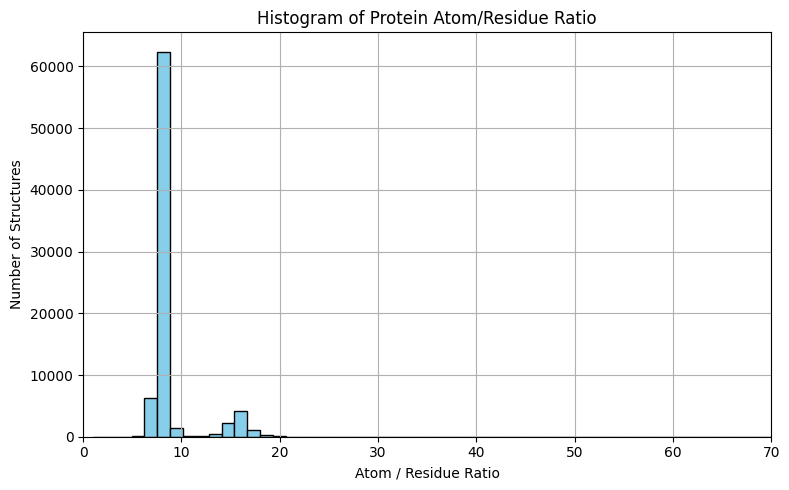

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV 파일 로드
csv_path = "/home/psh/protein-frame-flow/parse_general/meta/atom_residue_ratio.csv"
df = pd.read_csv(csv_path)

# 히스토그램 그리기 (x축 범위 제한)
plt.figure(figsize=(8, 5))
plt.hist(df["atom_residue_ratio"], bins=3000, color='skyblue', edgecolor='k')
plt.xlabel("Atom / Residue Ratio")
plt.ylabel("Number of Structures")
plt.title("Histogram of Protein Atom/Residue Ratio")
plt.xlim(0, 70)  # 👈 x축 범위 제한
plt.grid(True)
plt.tight_layout()

# 저장
plt.savefig("protein_atom_residue_ratio_histogram_limited.png", dpi=300)
plt.show()

In [13]:
import pandas as pd

# CSV 파일 로드
csv_path = "/home/psh/protein-frame-flow/parse_general/meta/atom_residue_ratio.csv"
df = pd.read_csv(csv_path)

# 5.0 미만인 행 필터링 후 pdb 열 출력
filtered_pdbs = df[df["atom_residue_ratio"] < 5.0]
print(filtered_pdbs.to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: '/home/psh/protein-frame-flow/parse_general/meta/atom_residue_ratio.csv'

In [16]:
import os

# 기준 디렉토리
meta_dir = "/home/psh/data/general/meta"

# 제거할 PDB ID 목록
target_ids = {
    "1c53", "1cwn", "1ian", "1ilt", "1mar",
    "1tgl", "1wzb", "1ym8", "2blm", "2q33",
    "3cbh", "3gnz", "3ipj", "4gls", "4ttj"
}

# 디렉토리 순회
for filename in os.listdir(meta_dir):
    filepath = os.path.join(meta_dir, filename)
    if not os.path.isfile(filepath):
        continue

    # 해당 파일에 target PDB ID가 하나라도 포함되면 삭제
    if filename.replace('.pkl', '') in target_ids:
        os.remove(filepath)
        print(f"❌ 삭제됨: {filename}")


❌ 삭제됨: 1ian.pkl
❌ 삭제됨: 1ilt.pkl
❌ 삭제됨: 1wzb.pkl
❌ 삭제됨: 1tgl.pkl
❌ 삭제됨: 1mar.pkl
❌ 삭제됨: 1c53.pkl
❌ 삭제됨: 2blm.pkl
❌ 삭제됨: 1cwn.pkl
❌ 삭제됨: 2q33.pkl
❌ 삭제됨: 1ym8.pkl
❌ 삭제됨: 3gnz.pkl
❌ 삭제됨: 3cbh.pkl
❌ 삭제됨: 3ipj.pkl
❌ 삭제됨: 4gls.pkl
❌ 삭제됨: 4ttj.pkl


In [18]:
import pandas as pd

# 대상 CSV 파일 경로
csv_path = "/home/psh/data/general/meta/metadata.csv"
output_path = "/home/psh/data/general/meta/metadata_atom_filtered.csv"
# 삭제 대상 PDB ID 목록
target_ids = {
    "1c53", "1cwn", "1ian", "1ilt", "1mar",
    "1tgl", "1wzb", "1ym8", "2blm", "2q33",
    "3cbh", "3gnz", "3ipj", "4gls", "4ttj"
}

# CSV 로드
df = pd.read_csv(csv_path)

# 대상 ID가 포함된 행 삭제 (pdb id 열 이름이 'pdb'라고 가정)
df_filtered = df[~df["pdb_name"].isin(target_ids)]

# 결과 덮어쓰기 저장
df_filtered.to_csv(output_path, index=False)
print(f"✅ 삭제 완료: {len(df) - len(df_filtered)}개 행 제거됨")

✅ 삭제 완료: 15개 행 제거됨


## 모종의 이유로 seq_len이 1~2로 잡히는 샘플들 

In [40]:
import pandas as pd

# CSV 파일 경로
csv_path = '/home/psh/data/general/meta/metadata.csv'

# CSV 읽기
df = pd.read_csv(csv_path)

# seq_len이 3 미만인 행 필터링
filtered_df = df[df['seq_len'] < 3]

# pdb_name과 seq_len 열만 선택
result = filtered_df[['pdb_name', 'seq_len']]

print(result)

# 필요하면 CSV로 저장
# result.to_csv('/home/psh/protein-frame-flow/parse_general/meta/filtered_seq_len_less_than_4.csv', index=False)


      pdb_name  seq_len
171       1a7z        2
204       1aa5        2
835       1c0q        2
836       1c0r        2
3314      1hc0        1
...        ...      ...
76450     7ltb        2
76725     7mhl        1
76726     7mhm        1
76727     7mho        1
76728     7mhq        1

[93 rows x 2 columns]


## train valid split 

In [6]:
import pandas as pd
import json
import random

# 경로 설정
metadata_path = "/home/psh/data/general/meta/metadata.csv"
cluster_json_path = "/home/psh/protein-frame-flow/parse_general/meta/filtered_pdb_clusters.json"
valid_output_path = "/home/psh/data/general/meta/metadata_valid.csv"
train_output_path = "/home/psh/data/general/meta/metadata_train.csv"

# 1. metadata.csv 불러오기
df = pd.read_csv(metadata_path)

# 2. cluster 정보 로드
with open(cluster_json_path, "r") as f:
    cluster_map = json.load(f)

# 3. pdb_id → cluster_id 매핑 만들기
pdb_to_cluster = {}
for cluster_id, pdb_list in cluster_map.items():
    for pdb_id in pdb_list:
        pdb_to_cluster[pdb_id.lower()] = cluster_id

# 4. 각 행에 cluster_id 열 추가 (없는 경우는 NaN)
df["pdb_name"] = df["pdb_name"].str.lower()
df["cluster_id"] = df["pdb_name"].map(pdb_to_cluster)

# 5. 유효한 cluster_id만 필터링
df = df.dropna(subset=["cluster_id"])

# 6. mode별로 분할
polymer_df = df[df["mode"] == "polymer"]
monomer_df = df[df["mode"] == "monomer"]

# 7. cluster 중복 없이 샘플링
def sample_unique_clusters(df, sample_size):
    sampled = []
    used_clusters = set()
    shuffled_df = df.sample(frac=1, random_state=42)
    for _, row in shuffled_df.iterrows():
        cluster_id = row["cluster_id"]
        if cluster_id not in used_clusters:
            sampled.append(row)
            used_clusters.add(cluster_id)
        if len(sampled) == sample_size:
            break
    return pd.DataFrame(sampled)

valid_polymer = sample_unique_clusters(polymer_df, 50)
valid_monomer = sample_unique_clusters(monomer_df, 50)

# 8. 검증 세트 생성
valid_df = pd.concat([valid_polymer, valid_monomer])

# 9. 검증 데이터의 cluster 목록 추출
valid_clusters = set(valid_df["cluster_id"])

# 10. 학습 세트는 valid와 동일한 cluster를 가진 행 제외
train_df = df[~df["cluster_id"].isin(valid_clusters)]

# 11. 결과 저장
valid_df.to_csv(valid_output_path, index=False)
train_df.to_csv(train_output_path, index=False)

print(f"✅ 검증 세트 저장 완료: {valid_output_path}")
print(f"✅ 학습 세트 저장 완료 (valid와 중복 cluster 제거): {train_output_path}")


✅ 검증 세트 저장 완료: /home/psh/data/general/meta/metadata_valid.csv
✅ 학습 세트 저장 완료 (valid와 중복 cluster 제거): /home/psh/data/general/meta/metadata_train.csv


In [7]:
import pandas as pd

# 학습 데이터 경로
train_csv_path = "/home/psh/data/general/meta/metadata_train.csv"

# CSV 파일 불러오기
df_train = pd.read_csv(train_csv_path)

# cluster_id 고윳값 개수 출력
num_unique_clusters = df_train["cluster_id"].nunique()
print(f"📦 metadata_train.csv에 존재하는 고유 cluster 수: {num_unique_clusters}")


📦 metadata_train.csv에 존재하는 고유 cluster 수: 19552


## filter by length and number of chains

In [3]:
import pandas as pd

# 경로
csv_file = '/home/psh/data/general/meta/metadata.csv'
txt_file = '/home/psh/protein-frame-flow/parse_general/meta/only_protein_1.txt'
long_pdb_file = '/home/psh/protein-frame-flow/parse_general/meta/long_protein.txt'

# 1. CSV 파일 불러오기
df = pd.read_csv(csv_file)

# 2. 조건에 맞는 행 필터링 (제거 대상)
mask = (df['modeled_seq_len'] >= 3000) | (df['num_chains'] >= 30)
filtered_df = df[mask]
remaining_df = df[~mask]  # 조건을 만족하지 않는 행들만 남김

# 제거할 pdb_name 리스트
remove_pdbs = set(filtered_df['pdb_name'].tolist())

# 3. long_pdb_file로 제거된 PDB 저장
with open(long_pdb_file, 'w') as f:
    for pdb in remove_pdbs:
        f.write(pdb + '\n')

# 4. 텍스트 파일에서 해당 pdb_name 제거
with open(txt_file, 'r') as f:
    lines = f.readlines()

# 각 줄을 strip 후 제거할 pdb가 아닌 것만 필터링
filtered_lines = [line for line in lines if line.strip() not in remove_pdbs]

# 덮어쓰기
with open(txt_file, 'w') as f:
    f.writelines(filtered_lines)

# 5. csv도 조건을 만족하지 않는 행들로 덮어쓰기
remaining_df.to_csv(csv_file, index=False)



## make clutser file 

In [ ]:
import pandas as pd
import json

# CSV 파일 경로
csv_path = "/public_data/BioMolDB_2024Oct21/cluster/graph_cluster/hash_level_cluster.csv"

# CSV 읽기
df = pd.read_csv(csv_path, header=None, names=["pdb_id", "cluster"])

# 결과 저장할 딕셔너리
cluster_dict = {}

# 중복 제거를 위한 집합
seen_real_pdb = set()

for _, row in df.iterrows():
    full_id = row["pdb_id"]
    cluster = row["cluster"]
    
    try:
        pdb, model, structure, occupancy = full_id.split("_")
    except ValueError:
        # 잘못된 형식 무시
        continue

    if model != "1" or structure != "1":
        continue

    if pdb in seen_real_pdb:
        continue

    seen_real_pdb.add(pdb)

    if cluster not in cluster_dict:
        cluster_dict[cluster] = []

    cluster_dict[cluster].append(pdb)

# JSON 파일로 저장
output_path = "/home/psh/protein-frame-flow/parse_general/meta/cluster_to_pdbs.json"
with open(output_path, "w") as f:
    json.dump(cluster_dict, f, indent=2)

print(f"Saved to {output_path}")


## check empty mask info file 

In [9]:
import os
import json

# 디렉토리 경로
masking_dir = "/home/psh/data/general/masking_index"

# 비어있는 파일 목록 저장
empty_files = []

# 디렉토리 내 모든 파일 검사
for fname in os.listdir(masking_dir):
    fpath = os.path.join(masking_dir, fname)
    # JSON 파일만 대상으로 함
    if not fname.endswith(".json"):
        continue

    try:
        with open(fpath, "r") as f:
            data = json.load(f)

        is_empty = False

        if isinstance(data, dict):
            if "interface_residues" in data and data["interface_residues"] == {}:
                print(f"{fname} doesn't have interface")
                is_empty = True

        elif isinstance(data, list):
            # 빈 1차원 리스트
            if data == []:
                is_empty = True
                print(f"{fname} doesn't have loop")
            # 빈 2차원 리스트: 예를 들어 [[], [], []]
            elif all(isinstance(elem, list) and len(elem) == 0 for elem in data):
                is_empty = True
                print(f"{fname} doesn't have loop")

        if is_empty:
            empty_files.append(fname)

    except Exception as e:
        print(f"⚠️ {fname} 읽기 실패: {e}")

# 결과 출력
if empty_files:
    print(f"❌ 비어있는 파일 수: {len(empty_files)}")
else:
    print("✅ 비어있는 파일 없음")


180l.json doesn't have interface
1a4m.json doesn't have interface
1a7u.json doesn't have interface
1a8u.json doesn't have interface
1aa5.json doesn't have interface
1aaz.json doesn't have interface
1ag9.json doesn't have interface
1agj.json doesn't have interface
1aie.json doesn't have loop
1ajj.json doesn't have loop
1akg.json doesn't have loop
1anx.json doesn't have interface
1aoh.json doesn't have interface
1awp.json doesn't have interface
1b0w.json doesn't have interface
1b2o.json doesn't have interface
1b66.json doesn't have interface
1b6q.json doesn't have loop
1b6v.json doesn't have interface
1b6z.json doesn't have interface
1b7d.json doesn't have loop
1b80.json doesn't have interface
1b82.json doesn't have interface
1b85.json doesn't have interface
1bb1.json doesn't have interface
1bft.json doesn't have interface
1bhd.json doesn't have interface
1bir.json doesn't have interface
1bm9.json doesn't have interface
1bte.json doesn't have interface
1bw9.json doesn't have interface
1b

In [10]:
import pandas as pd
import os

# 1. empty_files 리스트가 이미 있는 상태라고 가정
# 예: empty_files = ['1abc_A.json', '2xyz_B.json', ...]
empty_pdb_names = [os.path.splitext(f)[0] for f in empty_files]

# 2. 파일 경로 설정
valid_path = "/home/psh/data/general/meta/metadata_valid.csv"
train_path = "/home/psh/data/general/meta/metadata_train.csv"

# 3. CSV 파일 로드
valid_df = pd.read_csv(valid_path)
train_df = pd.read_csv(train_path)

# 4. 비어있는 PDB 샘플 제거
filtered_valid_df = valid_df[~valid_df["pdb_name"].isin(empty_pdb_names)]
filtered_train_df = train_df[~train_df["pdb_name"].isin(empty_pdb_names)]

# 5. 덮어쓰기 저장
filtered_valid_df.to_csv(valid_path, index=False)
filtered_train_df.to_csv(train_path, index=False)

print(f"✅ 제거 완료: {len(valid_df) - len(filtered_valid_df)}개 valid 샘플 제거")
print(f"✅ 제거 완료: {len(train_df) - len(filtered_train_df)}개 train 샘플 제거")


✅ 제거 완료: 4개 valid 샘플 제거
✅ 제거 완료: 2957개 train 샘플 제거


## monomer 양 끝단 mask 제거 

In [ ]:
import pandas as pd
import json
import os
from tqdm import tqdm

# CSV 파일 경로
csv_path = "/home/psh/data/general/meta/metadata.csv"

# 마스킹 인덱스 경로
masking_dir = "/home/psh/data/general/masking_index"

# CSV 파일 읽기
df = pd.read_csv(csv_path)

# monomer인 행만 필터링
monomer_df = df[df["mode"] == "monomer"]

for _, row in tqdm(monomer_df.iterrows(), total=len(monomer_df)):
    pdb_name = row["pdb_name"]
    seq_len = row["seq_len"]

    json_path = os.path.join(masking_dir, f"{pdb_name}.json")

    if not os.path.exists(json_path):
        continue  # 파일 없으면 스킵

    try:
        with open(json_path, "r") as f:
            data = json.load(f)

        # 안쪽 리스트 중에서 0 또는 seq_len-1을 포함한 리스트 제거
        filtered = [
            inner for inner in data
            if 0 not in inner and (seq_len - 1) not in inner
        ]

        # 덮어쓰기 저장
        with open(json_path, "w") as f:
            json.dump(filtered, f)

    except Exception as e:
        print(f"Error processing {json_path}: {e}")


## polymer 양 끝단 mask 제거 

In [ ]:
import os
import json

def clean_interface_residues_with_offset(data):
    chain_lengths = data["chain_lengths"]
    
    # 체인 이름 리스트 (예: ['A', 'B', 'E', 'F']) 순서대로 정렬
    chain_names = sorted(list(chain_lengths.keys()))
    
    # offset 계산
    offsets = {}
    current = 0
    for chain_name in chain_names:
        offsets[chain_name] = current
        current += chain_lengths[chain_name]

    # 체인 인덱스(str) ↔ 체인 이름 매핑
    chain_index_to_name = {str(i): name for i, name in enumerate(chain_names)}

    cleaned = {}

    for chain_idx_str, residue_blocks in data["interface_residues"].items():
        if chain_idx_str not in chain_index_to_name:
            print(f"[!] Chain index {chain_idx_str} not found in chain_lengths.")
            continue

        chain_name = chain_index_to_name[chain_idx_str]
        offset = offsets[chain_name]
        end = offset + chain_lengths[chain_name] - 1

        cleaned_blocks = []
        for block in residue_blocks:
            filtered = [idx for idx in block if idx != offset and idx != end]
            if filtered:
                cleaned_blocks.append(filtered)

        cleaned[chain_idx_str] = cleaned_blocks

    return {
        "interface_residues": cleaned,
        "chain_lengths": data["chain_lengths"]
    }

def process_directory(json_dir):
    for filename in os.listdir(json_dir):
        if not filename.endswith('.json'):
            continue
        
        filepath = os.path.join(json_dir, filename)
        with open(filepath, 'r') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                print(f"[!] Invalid JSON file: {filename}")
                continue
        print(data)
        if "chain_lengths" not in data:
            print(f"[-] Skipping {filename} (no 'interface_residues')")
            continue

        cleaned_data = clean_interface_residues_with_offset(data)

        # with open(filepath, 'w') as f:
        #     json.dump(cleaned_data, f, indent=4)
        #     print(f"[✓] Cleaned and saved: {filename}")

# 사용 예시
json_directory = "/home/psh/data/general/masking_index/"  # ← 여기를 본인의 디렉토리 경로로 바꾸세요
process_directory(json_directory)


[[42, 43, 44, 45, 46, 47, 48, 49, 50]]
[-] Skipping 2qff.json (no 'interface_residues')
[[72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84], [90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113], [120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134], [193, 194, 195, 196, 197, 198, 199, 200, 201, 202]]
[-] Skipping 1qqu.json (no 'interface_residues')
[[72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84], [90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113], [120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134], [193, 194, 195, 196, 197, 198, 199, 200, 201, 202]]
[-] Skipping 1bjv.json (no 'interface_residues')
[[14, 15, 16, 17, 18, 19, 20, 21, 22, 23], [100, 101, 102, 103, 104, 105, 106, 107], [114, 115, 116, 117, 118]]
[-] Skipping 1f0w.json (no 'interface_residues')
[[9, 10, 11, 12, 13, 14, 15], [93, 94, 95, 96, 97, 98, 99, 10

TypeError: 'int' object is not iterable

In [11]:
print(filepath)

/home/psh/data/general/masking_index/6sp7.json


## polymer mask에서 polymer chain이 너무 많은 경우 제거

In [5]:
import os
import json

dir_path = "/home/psh/data/general/masking_index"
errors = []
for filename in os.listdir(dir_path):
    if not filename.endswith('.json'):
        continue

    filepath = os.path.join(dir_path, filename)

    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"⚠️ JSON decode error in file: {filename}")
        continue

    if "chain_lengths" in data:
        chain_dict = data["chain_lengths"]
        for key in chain_dict:
            if not isinstance(key, str):
                continue
            if len(key) != 1:  # key가 한 글자가 아니면
                print(f"파일: {filename}, 잘못된 key: {key}")
                errors.append(filepath)
                break  # 하나라도 이상한 key가 있으면 해당 파일만 한 번 출력


파일: 6zjg.json, 잘못된 key: HHH
파일: 6xyj.json, 잘못된 key: AAA
파일: 6xy3.json, 잘못된 key: AAA
파일: 6xxx.json, 잘못된 key: AAA
파일: 6sqq.json, 잘못된 key: AAA
파일: 6sqt.json, 잘못된 key: AAA
파일: 6sqv.json, 잘못된 key: AAA
파일: 6sr7.json, 잘못된 key: AAA
파일: 7o5n.json, 잘못된 key: AAA
파일: 7o5q.json, 잘못된 key: AAA
파일: 7o5t.json, 잘못된 key: AAA
파일: 7o5v.json, 잘못된 key: AAA
파일: 7o5w.json, 잘못된 key: AAA
파일: 7o6x.json, 잘못된 key: BBB
파일: 5bkn.json, 잘못된 key: GG
파일: 5bkl.json, 잘못된 key: GG
파일: 6k3i.json, 잘못된 key: AA
파일: 6zlo.json, 잘못된 key: AA
파일: 6zm3.json, 잘못된 key: AAA
파일: 6k33.json, 잘못된 key: aA
파일: 7m1a.json, 잘못된 key: AAA
파일: 6xa1.json, 잘못된 key: LA
파일: 7on0.json, 잘못된 key: AAA
파일: 7omz.json, 잘못된 key: AAA
파일: 7omy.json, 잘못된 key: AAA
파일: 7omu.json, 잘못된 key: AAA
파일: 6yzy.json, 잘못된 key: AAA
파일: 6yzf.json, 잘못된 key: AAA
파일: 6yzd.json, 잘못된 key: AAA
파일: 2vvj.json, 잘못된 key: aa
파일: 6yyr.json, 잘못된 key: AAA
파일: 6yyq.json, 잘못된 key: AAA
파일: 6yyp.json, 잘못된 key: AAA
파일: 6yyo.json, 잘못된 key: AAA
파일: 6yyn.json, 잘못된 key: AAA
파일: 7vd6.json, 잘못된 key: 11


In [8]:
import pandas as pd
import os

# 1. empty_files 리스트가 이미 있는 상태라고 가정
# 예: empty_files = ['1abc_A.json', '2xyz_B.json', ...]
empty_pdb_names = [os.path.basename(f).split('.')[0] for f in errors]

# 2. 파일 경로 설정

train_path = "/home/psh/data/general/meta/metadata.csv"

# 3. CSV 파일 로드
train_df = pd.read_csv(train_path)

# 4. 비어있는 PDB 샘플 제거
filtered_train_df = train_df[~train_df["pdb_name"].isin(empty_pdb_names)]

# 5. 덮어쓰기 저장
filtered_train_df.to_csv(train_path, index=False)

print(f"✅ 제거 완료: {len(train_df) - len(filtered_train_df)}개 train 샘플 제거")


✅ 제거 완료: 460개 train 샘플 제거
